# iQuHack 2026 - Quantum Entanglement Distillation Game

In this game, you design quantum circuits to distill noisy Bell pairs and claim edges in a network.

**Game Flow**: Register -> Select Starting Node -> Design Circuits -> Claim Edges -> Score Points

In [3]:
%pip install -r requirements.txt

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 3.4 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 2.8 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from client import GameClient
from visualization import GraphTool
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import json
from pathlib import Path

## Session Management

Save/load your session to avoid re-registering.

In [4]:
SESSION_FILE = Path("session.json")

def save_session(client):
    if client.api_token:
        with open(SESSION_FILE, "w") as f:
            json.dump({"api_token": client.api_token, "player_id": client.player_id, "name": client.name}, f)
        print(f"Session saved.")

def load_session():
    if not SESSION_FILE.exists():
        return None
    with open(SESSION_FILE) as f:
        data = json.load(f)
    client = GameClient(api_token=data.get("api_token"))
    client.player_id = data.get("player_id")
    client.name = data.get("name")
    status = client.get_status()
    if status:
        print(f"Resumed: {client.player_id} | Score: {status.get('score', 0)} | Budget: {status.get('budget', 0)}")
        return client
    return None

In [5]:
# Try to resume existing session
client = load_session()

if not client:
    print("No saved session. Register below.")

Resumed: aj_020405 | Score: 0 | Budget: 77


## Step 1: Register

Skip this if you resumed a session above.

In [5]:
if client and client.api_token:
    print(f"Already registered as {client.player_id}")
else:
    client = GameClient()
    
    # CHANGE THESE to your unique values
    PLAYER_ID = "aj_020405"
    PLAYER_NAME = "Antonio Jesus Valenciano Motero"
    
    result = client.register(PLAYER_ID, PLAYER_NAME, location=input("remote or in_person: ").strip())
    
    if result.get("ok"):
        print(f"Registered! Token: {client.api_token[:20]}...")
        candidates = result["data"].get("starting_candidates", [])
        print(f"\nStarting candidates ({len(candidates)}):")
        for c in candidates:
            print(f"  - {c['node_id']}: {c['utility_qubits']} qubits, +{c['bonus_bell_pairs']} bonus")
        save_session(client)
    else:
        print(f"Failed: {result.get('error', {}).get('message')}")

Already registered as aj_020405


## Step 2: Select Starting Node

In [14]:
status = client.get_status()

if status.get('starting_node'):
    print(f"Starting node: {status['starting_node']}")
    print(f"Budget: {status['budget']} | Score: {status['score']}")
else:
    print("Select a starting node from the candidates shown above.")
    # Uncomment and modify:
    result = client.select_starting_node("St. Petersburg, Russia")
    print(result)

Select a starting node from the candidates shown above.
{'ok': True, 'data': {'success': True, 'starting_node': 'St. Petersburg, Russia', 'score': 0, 'budget': 75}}


## Step 3: Explore the Network

In [81]:
client.print_status()

Player: aj_020405 (Antonio Jesus Valenciano Motero)
Score: 8 | Budget: 70 bell pairs
Active: Yes
Starting node: St. Petersburg, Russia
Owned: 3 nodes, 3 edges
Claimable edges: 12
  - ['Stockholm, Sweden', 'Tallinn, Estonia']: threshold=0.90, difficulty=3
  - ['Helsinki, Finland', 'Turku, Finland']: threshold=0.90, difficulty=1
  - ['Helsinki, Finland', 'Tampere, Finland']: threshold=0.90, difficulty=1
  ... and 9 more


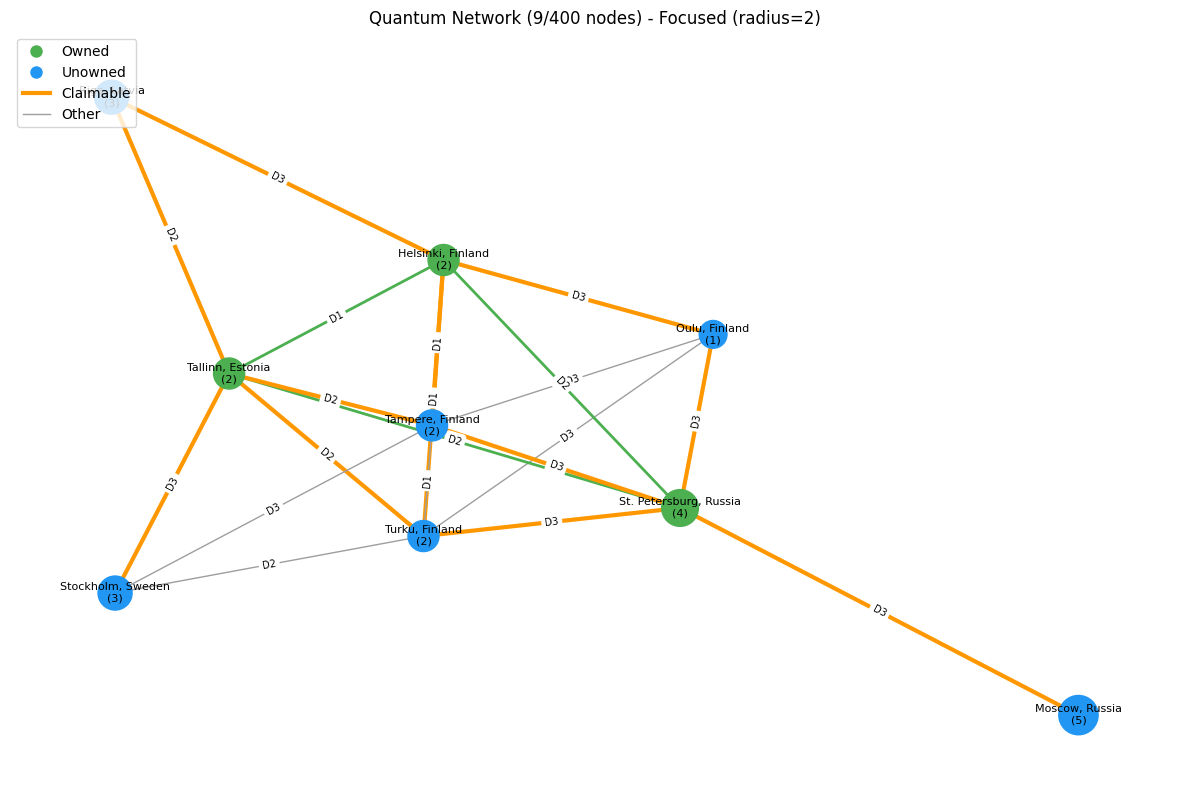

In [80]:
# Visualize the network (focused around your nodes)
viz = GraphTool(client.get_cached_graph())
owned = set(client.get_status().get('owned_nodes', []))
viz.render(owned)

## Step 4: Design a Distillation Circuit

For N Bell pairs, qubits are paired outside-in:
- Pair 0: qubits {0, 2N-1}
- Pair 1: qubits {1, 2N-2}
- ...
- Final pair: qubits {N-1, N}

Design a circuit that improves fidelity through LOCC operations.

In [6]:
import numpy as np

In [63]:
def create_distillation_circuit():
    """
    Estrategia: Protección de Fase (Z-Error Correction).
    Convierte errores Z en X usando Hadamards para que los CNOTs los detecten.
    Ideal cuando la fidelidad se estanca en ~0.60 - 0.70.
    """
    # 4 Qubits (2 Pares)
    # Alice: 0, 1 | Bob: 2, 3
    # Par Sacrificio: 0 - 3
    # Par Target:     1 - 2
    qr = QuantumRegister(4, 'q')
    cr = ClassicalRegister(3, 'c') # c[0]=Alice, c[1]=Bob, c[2]=Flag
    
    qc = QuantumCircuit(qr, cr)
    
    # --- 1. CAMBIO DE BASE (Las "Rotaciones" o H dors) ---
    # Aplicamos H a todos para convertir Ruido Z -> Ruido X
    qc.h(qr)
    
    # --- 2. CNOTs BILATERALES ---
    # Alice: Target(1) controla Sacrificio(0)
    qc.cx(1, 0)
    # Bob: Target(2) controla Sacrificio(3)
    qc.cx(2, 3)
    
    # --- 3. REVERTIR BASE EN EL TARGET ---
    # Importante: Solo revertimos los Targets para recuperar el estado Bell
    # Los sacrificios se quedan en base X para la medición
    qc.h(1)
    qc.h(2)
    
    # --- 4. MEDICIÓN ---
    qc.measure(0, 0) # Medida Alice -> bit 0
    qc.measure(3, 1) # Medida Bob   -> bit 1
    
    # --- 5. CÁLCULO DEL FLAG (Sin errores de tipo) ---
    # Truco: Reusamos el qubit 0 (ya medido) para calcular la paridad.
    # Si bit 0 y bit 1 son iguales -> Flag 0 (Éxito)
    # Si bit 0 y bit 1 son distintos -> Flag 1 (Fallo)
    
    qc.reset(0) # Limpiamos el qubit 0 para usarlo de calculadora
    
    # Si c[0] es 1, aplicamos X
    with qc.if_test((cr[0], 1)):
        qc.x(0)
        
    # Si c[1] es 1, aplicamos X
    # Resultado: Si eran iguales (00 o 11), q0 acabará en 0. 
    # Si eran distintos (01 o 10), q0 acabará en 1.
    with qc.if_test((cr[1], 1)):
        qc.x(0)
        
    # Medimos el resultado en el bit de flag (índice 2)
    qc.measure(0, 2)

    return qc

circuit = create_distillation_circuit()
print(circuit.draw(output='text'))

     ┌───┐┌───┐     ┌─┐       ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐»
q_0: ┤ H ├┤ X ├─────┤M├─|0>───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ X ├  End-0 ├»
     ├───┤└─┬─┘┌───┐└╥┘       └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘»
q_1: ┤ H ├──■──┤ H ├─╫───────────╫─────────────────────────╫───────────────────»
     ├───┤     ├───┤ ║           ║                         ║                   »
q_2: ┤ H ├──■──┤ H ├─╫───────────╫─────────────────────────╫───────────────────»
     ├───┤┌─┴─┐└┬─┬┘ ║           ║                         ║                   »
q_3: ┤ H ├┤ X ├─┤M├──╫───────────╫─────────────────────────╫───────────────────»
     └───┘└───┘ └╥┘  ║      ┌────╨────┐               ┌────╨────┐              »
c: 3/════════════╩═══╩══════╡ c_0=0x1 ╞═══════════════╡ c_1=0x1 ╞══════════════»
                 1   0      └─────────┘               └─────────┘              »
«      ┌─┐
«q_0: ─┤M├
«      └╥┘
«q_1: ──╫─
«       ║ 
«q_2: ──╫─
«       ║ 
«q_3: ──╫─
«       ║ 
«c: 3/══╩═

## Step 5: Claim an Edge

In [83]:
# Find claimable edges
claimable = client.get_claimable_edges()
claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))

print(f"Claimable edges ({len(claimable)}):")
for edge in claimable_sorted[:]:
    print(f"  {edge['edge_id']} - threshold: {edge['base_threshold']:.3f}, difficulty: {edge['difficulty_rating']}")

Claimable edges (12):
  ['Helsinki, Finland', 'Turku, Finland'] - threshold: 0.900, difficulty: 1
  ['Helsinki, Finland', 'Tampere, Finland'] - threshold: 0.900, difficulty: 1
  ['Tallinn, Estonia', 'Turku, Finland'] - threshold: 0.900, difficulty: 2
  ['Tallinn, Estonia', 'Tampere, Finland'] - threshold: 0.900, difficulty: 2
  ['Riga, Latvia', 'Tallinn, Estonia'] - threshold: 0.900, difficulty: 2
  ['Stockholm, Sweden', 'Tallinn, Estonia'] - threshold: 0.900, difficulty: 3
  ['Helsinki, Finland', 'Oulu, Finland'] - threshold: 0.900, difficulty: 3
  ['Oulu, Finland', 'St. Petersburg, Russia'] - threshold: 0.900, difficulty: 3
  ['Helsinki, Finland', 'Riga, Latvia'] - threshold: 0.900, difficulty: 3
  ['Moscow, Russia', 'St. Petersburg, Russia'] - threshold: 0.900, difficulty: 3
  ['St. Petersburg, Russia', 'Tampere, Finland'] - threshold: 0.900, difficulty: 3
  ['St. Petersburg, Russia', 'Turku, Finland'] - threshold: 0.900, difficulty: 3


In [87]:
# Claim an edge
if claimable:
    target = claimable_sorted[5]  # Easiest edge
    edge_id = tuple(target['edge_id'])
    
    circuit = create_distillation_circuit()
    num_bell_pairs = 2
    flag_bit = 2  # Classical bit for post-selection (keep when flag=0)
    
    print(f"Claiming {edge_id} (threshold: {target['base_threshold']:.3f})...")
    
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")

Claiming ('Stockholm, Sweden', 'Tallinn, Estonia') (threshold: 0.900)...
Success: True
Fidelity: 1.0000 (threshold: 0.9000)
Success probability: 0.5625


## Step 6: Check Progress

In [57]:
client.print_status()

Player: aj_020405 (Antonio Jesus Valenciano Motero)
Score: 0 | Budget: 74 bell pairs
Active: Yes
Starting node: St. Petersburg, Russia
Owned: 1 nodes, 0 edges
Claimable edges: 6
  - ['Helsinki, Finland', 'St. Petersburg, Russia']: threshold=0.90, difficulty=2
  - ['Oulu, Finland', 'St. Petersburg, Russia']: threshold=0.90, difficulty=3
  - ['Moscow, Russia', 'St. Petersburg, Russia']: threshold=0.90, difficulty=3
  ... and 3 more


In [58]:
# View leaderboard
leaderboard = client.get_leaderboard()["leaderboard"]
print("Leaderboard:")
for i, p in enumerate(leaderboard[:10]):
    print(f"{i+1}. {p.get('player_id', 'Unknown'):20} Score: {p.get('score', 0)}")

Leaderboard:
1. victor_prime         Score: 248
2. test_claude_1523b    Score: 231
3. ahkatlio_76f0869e    Score: 225
4. tumcuctom            Score: 196
5. riverst03            Score: 170
6. TarekR03             Score: 168
7. Nakbar0              Score: 168
8. testetst12345        Score: 146
9. invic                Score: 142
10. xstm                 Score: 129


## Tips

- **Failed attempts are free** - only successful claims cost bell pairs
- **More bell pairs** can improve fidelity but cost more budget
- **Vertex rewards** are competitive - top players by claim strength earn rewards
- **Budget management** is key - if budget reaches 0, you're eliminated

Good luck!

In [13]:
# Restart game (uncomment to use)
# result = client.restart()
# print(result)